# 🦍 Notebook 02 — Movement Analysis
Computes step-level and daily-level movement metrics:
- Step lengths (distance per 10-min interval)
- Daily path lengths (total distance covered per day)
- Movement speed and bearing
- Turning angle distributions
- Temporal patterns (hourly, monthly)
- Net squared displacement
- Nest-to-nest predictability


## Cell 1 — Imports & Load Data

In [2]:
import sys, os, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

project_root = os.path.abspath('..')
sys.path.insert(0, project_root)
from src.movement_metrics import (
    add_step_metrics, daily_path_length,
    net_squared_displacement, nest_to_nest_distance, movement_summary
)

DATA_PATH = os.path.join(project_root, 'data', 'processed', 'gorilla_gps_clean.csv')
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError('Run Notebook 01 first to generate gorilla_gps_clean.csv')

df = pd.read_csv(DATA_PATH, parse_dates=['timestamp','date'])
print(f'Data loaded: {len(df):,} rows')
GROUPS = sorted(df['group_id'].unique())
print(f'Groups: {GROUPS}')

Data loaded: 105,143 rows
Groups: ['Amahoro', 'Hirwa', 'Kwitonda', 'Pablo', 'Susa', 'Umubano']


## Cell 2 — Compute Step-Level Metrics
Each consecutive GPS fix pair within a day is a *step*. We compute:
- **step_length_km** — distance between consecutive fixes (Haversine)
- **speed_kmh** — movement speed
- **bearing_deg** — direction of travel
- **turning_angle_deg** — change in direction

In [3]:
print('Computing step-level movement metrics...')
df = add_step_metrics(df)

# Remove cross-day steps (large time gaps = night between follows)
df['time_diff_hr'] = df.groupby('group_id')['timestamp'].diff().dt.total_seconds() / 3600
df.loc[df['time_diff_hr'] > 1, 'step_length_km'] = np.nan  # Drop overnight steps
df.loc[df['time_diff_hr'] > 1, 'speed_kmh'] = np.nan
df.loc[df['time_diff_hr'] > 1, 'turning_angle_deg'] = np.nan

valid_steps = df['step_length_km'].notna().sum()
print(f'Valid steps computed: {valid_steps:,}')
print()
print('Step length summary (km):')
print(df['step_length_km'].describe().round(4))

Computing step-level movement metrics...
Valid steps computed: 102,953

Step length summary (km):
count    102953.0000
mean          0.0277
std           0.0211
min           0.0000
25%           0.0116
50%           0.0224
75%           0.0385
max           0.1691
Name: step_length_km, dtype: float64


## Cell 3 — Daily Path Lengths

In [4]:
daily_df = daily_path_length(df)
print('Daily movement summary:')
print(movement_summary(daily_df))

# Save
daily_df.to_csv(os.path.join(project_root,'data','processed','daily_distances.csv'), index=False)
print('\n✅ Saved to data/processed/daily_distances.csv')

Daily movement summary:
   group_id  mean_km  median_km  std_km  min_km  max_km      cv  n_days
0   Amahoro   1.3207     1.3234  0.1370  0.9822  1.6682  0.1037     365
1     Hirwa   1.1823     1.1862  0.1265  0.7745  1.7058  0.1070     365
2  Kwitonda   1.2646     1.2594  0.1341  0.9608  1.6841  0.1060     365
3     Pablo   1.5139     1.5185  0.1620  0.9273  1.9476  0.1070     365
4      Susa   1.4251     1.4169  0.1528  1.0044  1.8248  0.1072     365
5   Umubano   1.1197     1.1179  0.1204  0.8041  1.4529  0.1075     365

✅ Saved to data/processed/daily_distances.csv


## Cell 4 — Visualize Step Length Distributions

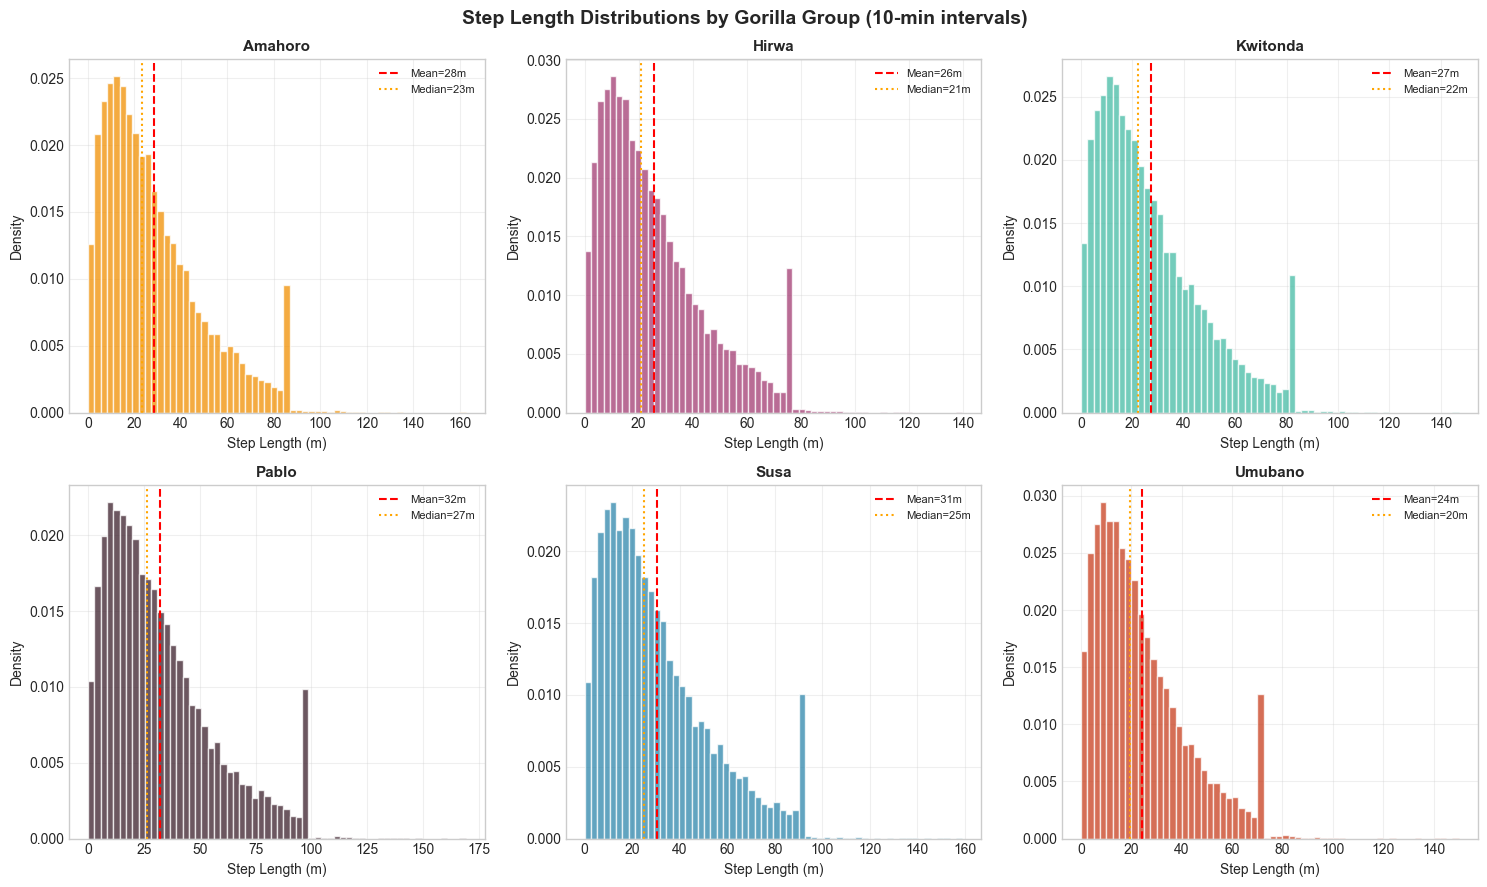

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
COLORS = {'Susa':'#2E86AB','Hirwa':'#A23B72','Amahoro':'#F18F01',
          'Umubano':'#C73E1D','Pablo':'#3B1F2B','Kwitonda':'#44BBA4'}

for i, group in enumerate(GROUPS):
    steps = df[df['group_id'] == group]['step_length_m'].dropna()
    ax = axes[i]
    ax.hist(steps, bins=60, color=COLORS.get(group,'gray'),
            alpha=0.75, edgecolor='white', density=True)
    ax.axvline(steps.mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'Mean={steps.mean():.0f}m')
    ax.axvline(steps.median(), color='orange', linestyle=':',
               linewidth=1.5, label=f'Median={steps.median():.0f}m')
    ax.set_title(f'{group}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Step Length (m)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Step Length Distributions by Gorilla Group (10-min intervals)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(project_root,'outputs','figures','02_step_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 5 — Daily Path Length Distributions & Temporal Patterns

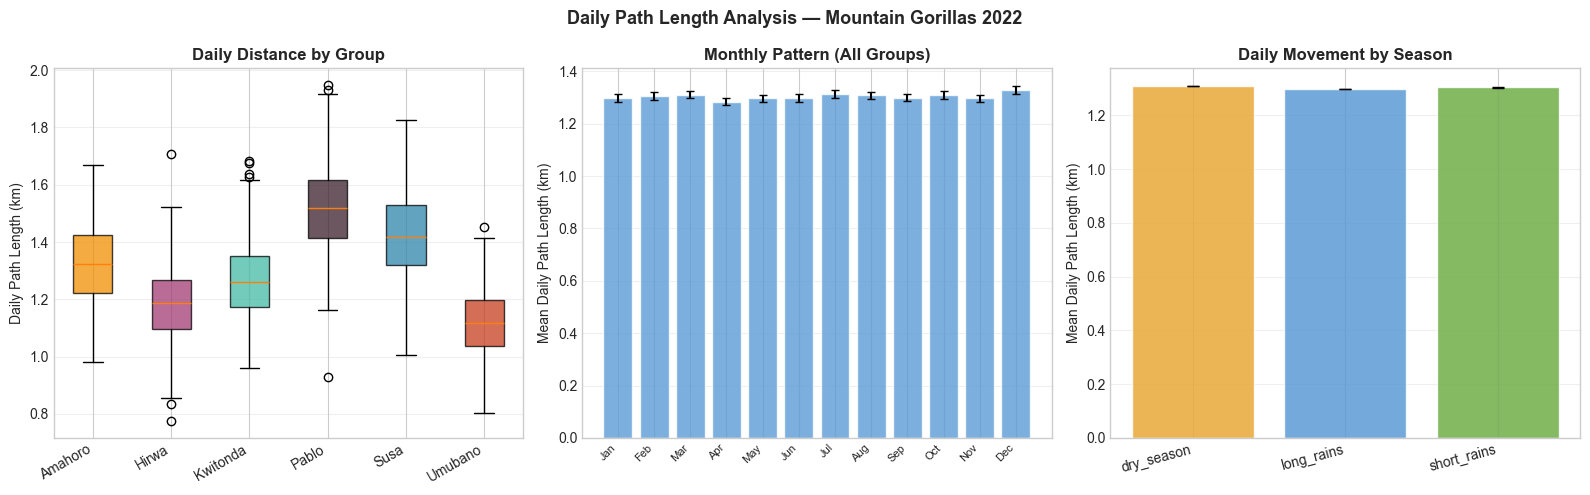

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# A) Box plot by group
ax = axes[0]
data_by_group = [daily_df[daily_df['group_id']==g]['daily_path_km'].dropna() for g in GROUPS]
bp = ax.boxplot(data_by_group, labels=GROUPS, patch_artist=True, notch=False)
for patch, group in zip(bp['boxes'], GROUPS):
    patch.set_facecolor(COLORS.get(group,'gray'))
    patch.set_alpha(0.75)
ax.set_xticklabels(GROUPS, rotation=30, ha='right')
ax.set_ylabel('Daily Path Length (km)')
ax.set_title('Daily Distance by Group', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# B) Monthly trend
ax = axes[1]
daily_df2 = daily_df.copy()
daily_df2['month'] = pd.to_datetime(daily_df2['date']).dt.month
monthly_all = daily_df2.groupby('month')['daily_path_km'].mean()
monthly_se  = daily_df2.groupby('month')['daily_path_km'].sem()
months = range(1, 13)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.bar(months, monthly_all.reindex(months).values, color='#5B9BD5',
       alpha=0.8, edgecolor='white')
ax.errorbar(months, monthly_all.reindex(months).values,
            yerr=monthly_se.reindex(months).values,
            fmt='none', color='black', capsize=3)
ax.set_xticks(list(months))
ax.set_xticklabels(month_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean Daily Path Length (km)')
ax.set_title('Monthly Pattern (All Groups)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# C) Season comparison
ax = axes[2]
season_means = df.merge(daily_df, on=['group_id','date'])
season_summary = season_means.groupby('season')['daily_path_km'].mean()
season_se = season_means.groupby('season')['daily_path_km'].sem()
s_colors = {'dry_season':'#E8A838','long_rains':'#5B9BD5','short_rains':'#70AD47'}
s_colors_list = [s_colors.get(s,'gray') for s in season_summary.index]
bars = ax.bar(season_summary.index, season_summary.values,
              color=s_colors_list, alpha=0.85, edgecolor='white')
ax.errorbar(season_summary.index, season_summary.values,
            yerr=season_se.values, fmt='none', color='black', capsize=4)
ax.set_ylabel('Mean Daily Path Length (km)')
ax.set_title('Daily Movement by Season', fontweight='bold')
ax.set_xticklabels(season_summary.index, rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Daily Path Length Analysis — Mountain Gorillas 2022',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(project_root,'outputs','figures','02_daily_distances.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 6 — Turning Angle Distribution (Random Walk Test)

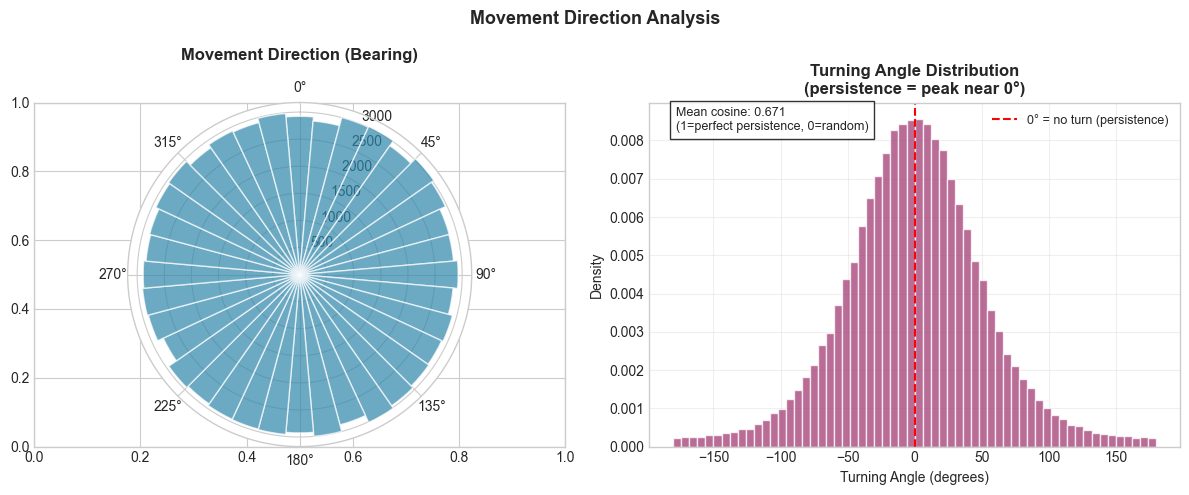

Mean direction cosine: 0.6708
  > 0 indicates directional persistence (correlated random walk)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# A) Rose plot of bearing directions
ax = axes[0]
bearings = df['bearing_deg'].dropna()
bearings_rad = np.radians(bearings)
n_bins = 36
bin_edges = np.linspace(0, 2*np.pi, n_bins+1)
counts, _ = np.histogram(bearings_rad, bins=bin_edges)
width = 2*np.pi / n_bins
ax = plt.subplot(121, projection='polar')
bars = ax.bar(bin_edges[:-1], counts, width=width, alpha=0.7,
              color='#2E86AB', edgecolor='white')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_title('Movement Direction (Bearing)', fontweight='bold', pad=15)

# B) Turning angle histogram (CRW test)
ax2 = plt.subplot(122)
turns = df['turning_angle_deg'].dropna()
ax2.hist(turns, bins=60, color='#A23B72', alpha=0.75, edgecolor='white', density=True)
# Reference: uniform distribution = straight-line movement would be ~0
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5,
           label='0° = no turn (persistence)')
ax2.set_xlabel('Turning Angle (degrees)')
ax2.set_ylabel('Density')
ax2.set_title('Turning Angle Distribution\n(persistence = peak near 0°)', fontweight='bold')
mean_cos = np.cos(np.radians(turns)).mean()
ax2.text(0.05, 0.92, f'Mean cosine: {mean_cos:.3f}\n(1=perfect persistence, 0=random)',
         transform=ax2.transAxes, fontsize=9,
         bbox=dict(facecolor='white', alpha=0.8))
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('Movement Direction Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(project_root,'outputs','figures','02_turning_angles.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean direction cosine: {mean_cos:.4f}')
print(f'  > 0 indicates directional persistence (correlated random walk)')

## Cell 7 — Nest-to-Nest Distance (Predictability)

Nest-to-Nest Distance Summary (km):
          count   mean    std    min    25%    50%    75%    max
group_id                                                        
Amahoro   356.0  0.410  0.203  0.025  0.268  0.369  0.534  1.025
Hirwa     357.0  0.367  0.192  0.034  0.216  0.336  0.488  1.005
Kwitonda  359.0  0.382  0.197  0.011  0.244  0.360  0.513  1.073
Pablo     359.0  0.451  0.235  0.019  0.269  0.417  0.596  1.196
Susa      358.0  0.436  0.230  0.011  0.265  0.414  0.591  1.221
Umubano   358.0  0.336  0.177  0.005  0.192  0.314  0.465  0.867


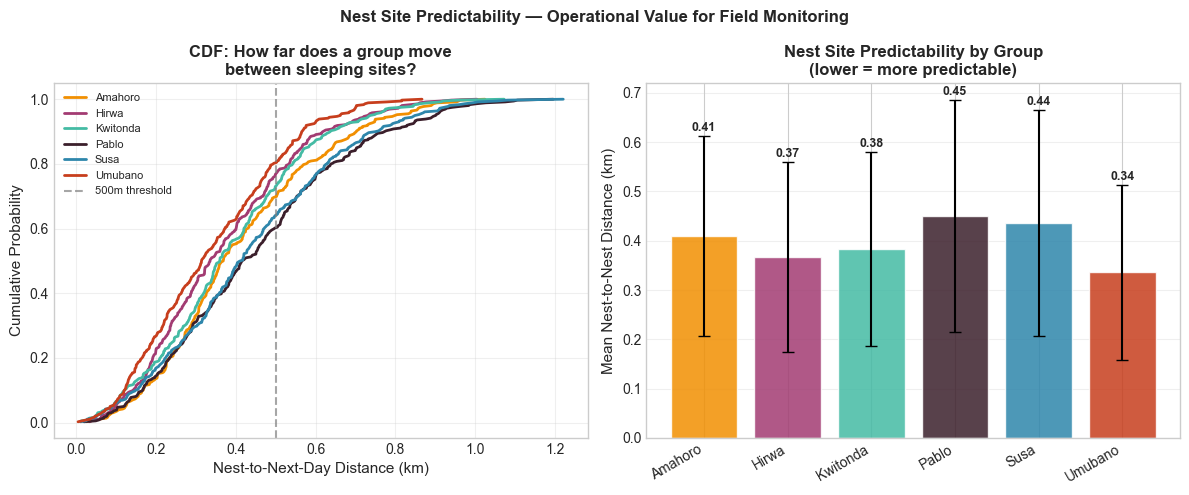


📍 KEY FINDING:
   Mean nest-to-nest distance: 0.397 km
   % of nights within 500m of previous nest: 70.4%
   → Groups are highly predictable from previous nest sites


In [11]:
nest_df = nest_to_nest_distance(df)
nest_df.to_csv(os.path.join(project_root,'data','processed','nest_distances.csv'), index=False)

print('Nest-to-Nest Distance Summary (km):')
print(nest_df.groupby('group_id')['nest_to_nest_km'].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CDF (Cumulative Distribution Function) per group
ax = axes[0]
for group in GROUPS:
    sub = nest_df[nest_df['group_id']==group]['nest_to_nest_km'].dropna().sort_values()
    cdf = np.arange(1, len(sub)+1) / len(sub)
    ax.plot(sub, cdf, label=group, color=COLORS.get(group,'gray'), linewidth=2)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='500m threshold')
ax.set_xlabel('Nest-to-Next-Day Distance (km)', fontsize=11)
ax.set_ylabel('Cumulative Probability', fontsize=11)
ax.set_title('CDF: How far does a group move\nbetween sleeping sites?', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Mean ± SD per group
ax = axes[1]
means = nest_df.groupby('group_id')['nest_to_nest_km'].mean().reindex(GROUPS)
stds  = nest_df.groupby('group_id')['nest_to_nest_km'].std().reindex(GROUPS)
bars = ax.bar(GROUPS, means.values,
              color=[COLORS.get(g,'gray') for g in GROUPS],
              alpha=0.85, edgecolor='white')
ax.errorbar(GROUPS, means.values, yerr=stds.values,
            fmt='none', color='black', capsize=4, linewidth=1.5)
for bar, m, s in zip(bars, means.values, stds.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.01,
            f'{m:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Mean Nest-to-Nest Distance (km)', fontsize=11)
ax.set_title('Nest Site Predictability by Group\n(lower = more predictable)', fontweight='bold')
ax.set_xticklabels(GROUPS, rotation=30, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Nest Site Predictability — Operational Value for Field Monitoring',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(project_root,'outputs','figures','02_nest_predictability.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Key finding
overall_mean = nest_df['nest_to_nest_km'].mean()
pct_under_500m = (nest_df['nest_to_nest_km'] < 0.5).mean() * 100
print(f'\n📍 KEY FINDING:')
print(f'   Mean nest-to-nest distance: {overall_mean:.3f} km')
print(f'   % of nights within 500m of previous nest: {pct_under_500m:.1f}%')
print(f'   → Groups are highly predictable from previous nest sites')

## Cell 8 — Net Squared Displacement

Computing net squared displacement...


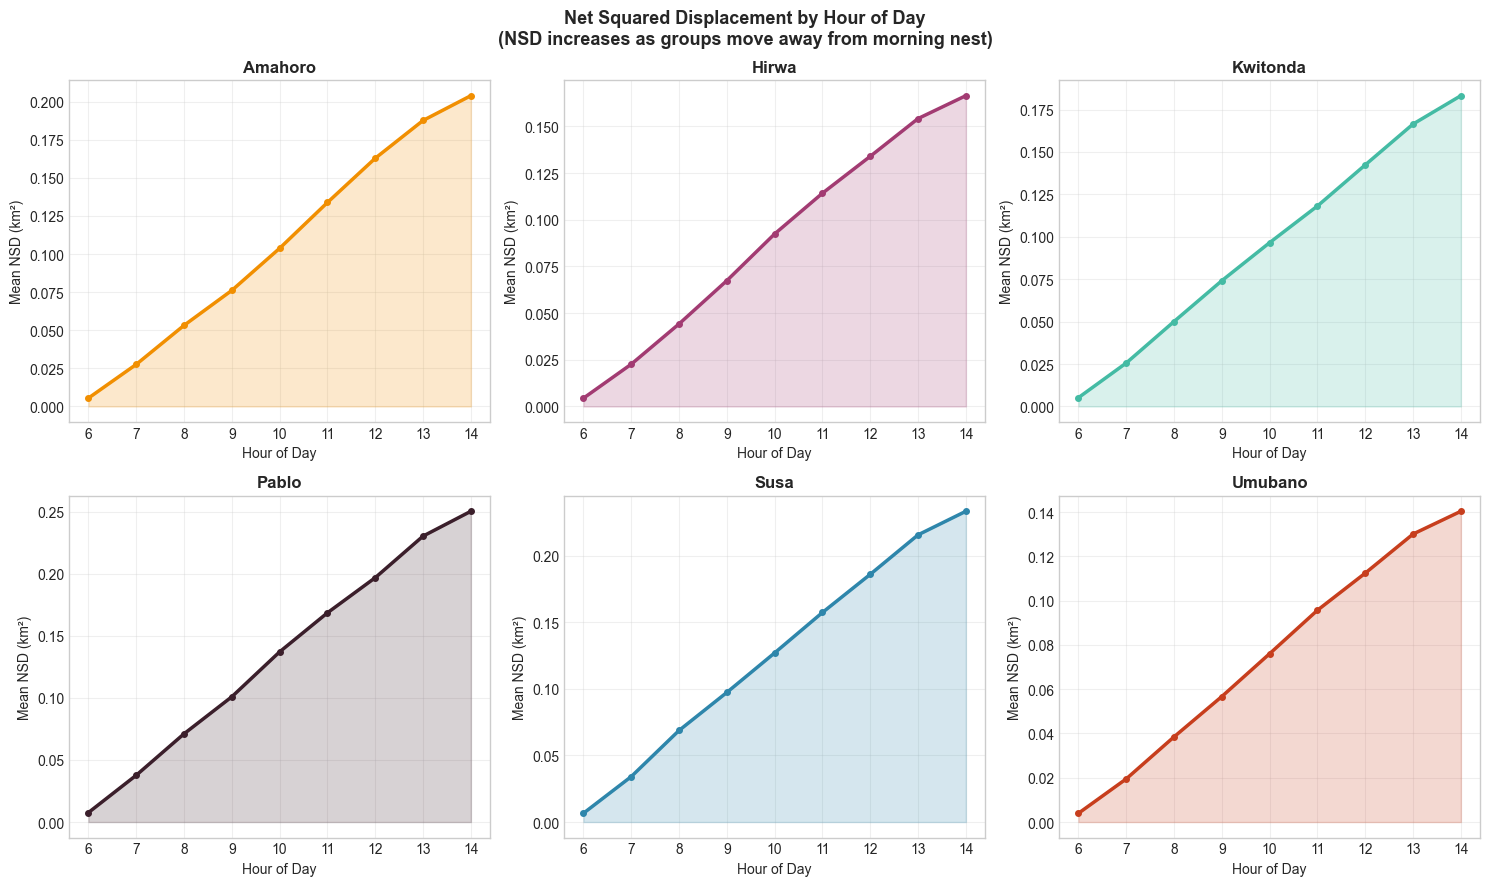

In [9]:
print('Computing net squared displacement...')
df_nsd = net_squared_displacement(df)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, group in enumerate(GROUPS):
    sub = df_nsd[df_nsd['group_id']==group].copy()
    sub['hour_frac'] = sub['timestamp'].dt.hour + sub['timestamp'].dt.minute/60
    hourly_nsd = sub.groupby(sub['timestamp'].dt.hour)['nsd_km2'].mean()

    ax = axes[i]
    ax.plot(hourly_nsd.index, hourly_nsd.values,
            color=COLORS.get(group,'gray'), linewidth=2.5, marker='o', markersize=4)
    ax.fill_between(hourly_nsd.index, hourly_nsd.values, alpha=0.2,
                    color=COLORS.get(group,'gray'))
    ax.set_title(f'{group}', fontweight='bold')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Mean NSD (km²)')
    ax.grid(alpha=0.3)
    ax.set_xticks(range(6, 15))

plt.suptitle('Net Squared Displacement by Hour of Day\n(NSD increases as groups move away from morning nest)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(project_root,'outputs','figures','02_nsd.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 9 — Summary Statistics Table

In [10]:
summary = movement_summary(daily_df)
summary.columns = ['Group','Mean (km)','Median (km)','SD (km)','Min (km)','Max (km)','CV','N days']
summary = summary.round(3)
print('='*70)
print('DAILY MOVEMENT SUMMARY STATISTICS')
print('='*70)
print(summary.to_string(index=False))
print('='*70)
print(f'\nOverall mean daily path: {daily_df["daily_path_km"].mean():.3f} km')
print(f'Overall SD             : {daily_df["daily_path_km"].std():.3f} km')
summary.to_csv(os.path.join(project_root,'outputs','reports','movement_summary.csv'), index=False)
print('\n✅ Summary saved to outputs/reports/movement_summary.csv')

DAILY MOVEMENT SUMMARY STATISTICS
   Group  Mean (km)  Median (km)  SD (km)  Min (km)  Max (km)    CV  N days
 Amahoro      1.321        1.323    0.137     0.982     1.668 0.104     365
   Hirwa      1.182        1.186    0.126     0.774     1.706 0.107     365
Kwitonda      1.265        1.259    0.134     0.961     1.684 0.106     365
   Pablo      1.514        1.518    0.162     0.927     1.948 0.107     365
    Susa      1.425        1.417    0.153     1.004     1.825 0.107     365
 Umubano      1.120        1.118    0.120     0.804     1.453 0.108     365

Overall mean daily path: 1.304 km
Overall SD             : 0.194 km

✅ Summary saved to outputs/reports/movement_summary.csv
